<a href="https://colab.research.google.com/github/edisto36/First-rep/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Loading Data ---
Data loaded successfully.
Dimensions: 50 rows, 4 columns

--- First 5 Rows ---
        State  Population  Murder.Rate Abbreviation
0     Alabama     4779736          5.7           AL
1      Alaska      710231          5.6           AK
2     Arizona     6392017          4.7           AZ
3    Arkansas     2915918          5.6           AR
4  California    37253956          4.4           CA

--- Data Types & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   State         50 non-null     object 
 1   Population    50 non-null     int64  
 2   Murder.Rate   50 non-null     float64
 3   Abbreviation  50 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.7+ KB
None

--- Univariate Analysis ---

[Murder Rate Summary]
count    50.000000
mean      4.066000
std       1.915736
min       0.900

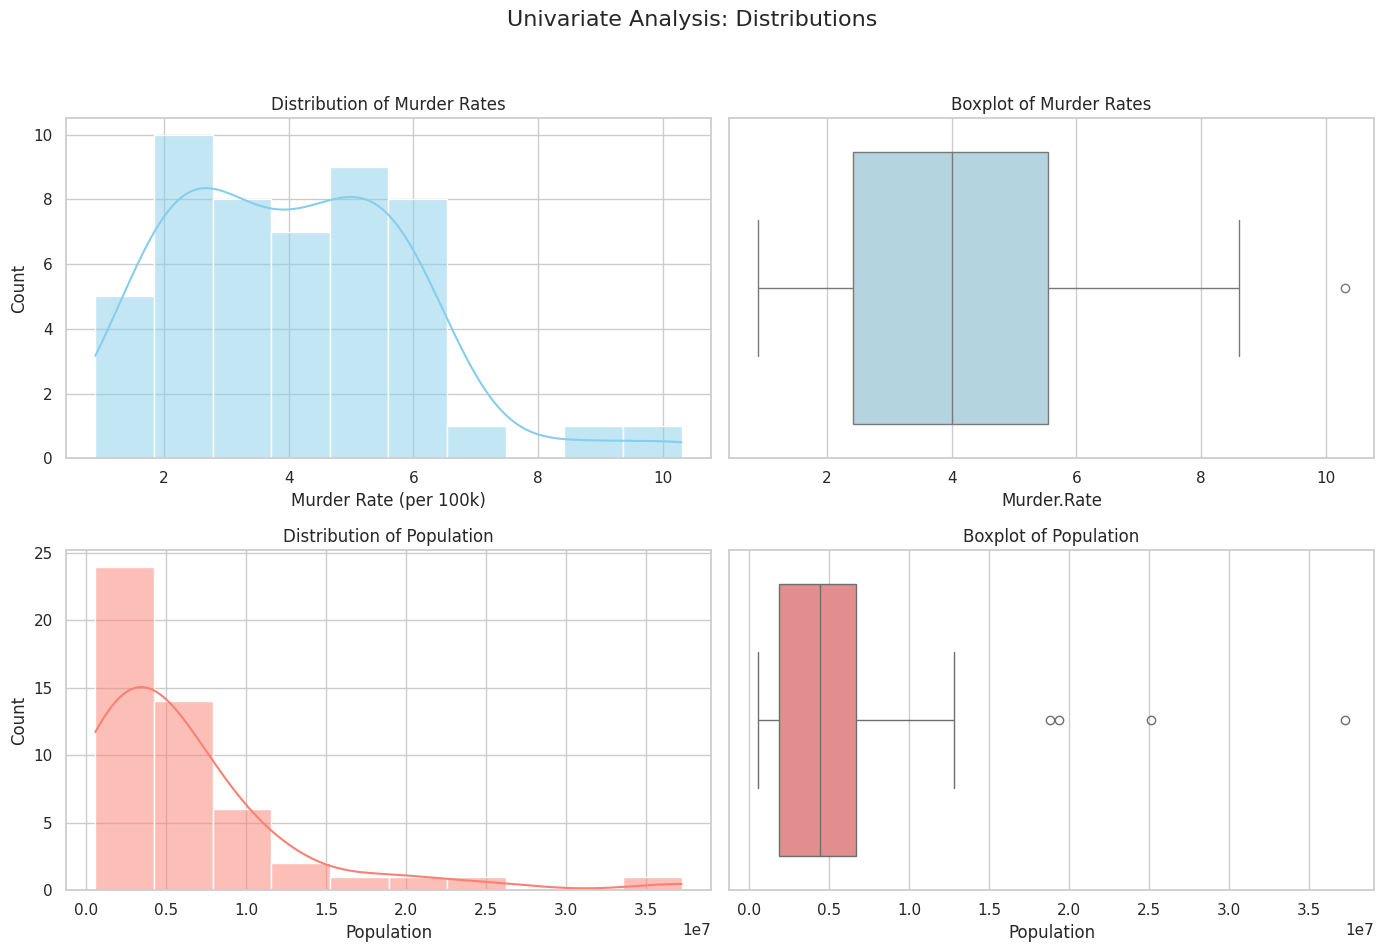


--- Bivariate Analysis ---
Correlation between Population and Murder Rate: 0.1821
Interpretation: Weak or no linear relationship.


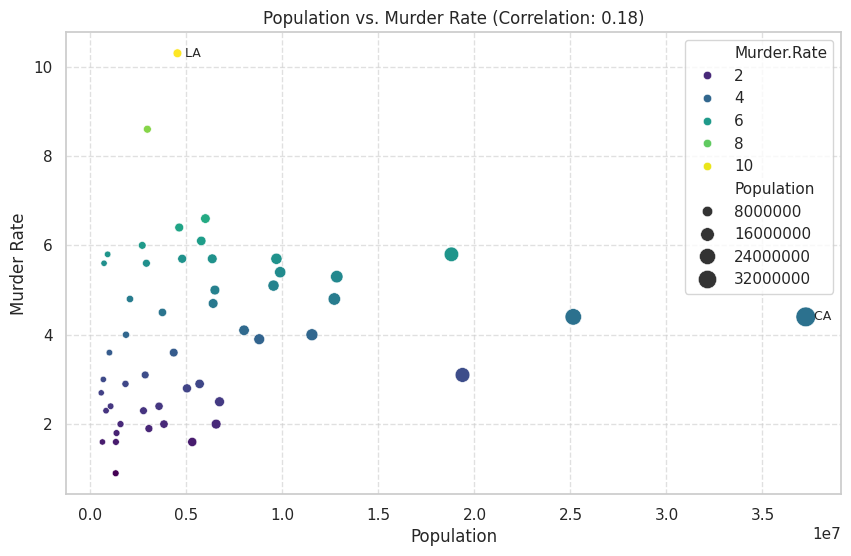


--- Analysis Complete ---


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the visual style for the plotss
sns.set_theme(style="whitegrid")

def load_and_inspect(filepath):
    """Loads the dataset and prints basic info."""
    print("--- Loading Data ---")
    try:
        df = pd.read_csv(filepath)
        print("Data loaded successfully.")
        print(f"Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
        print("\n--- First 5 Rows ---")
        print(df.head())
        print("\n--- Data Types & Missing Values ---")
        print(df.info())
        return df
    except FileNotFoundError:
        print(f"Error: File '{filepath}' not found. Please ensure the file is in the same directory.")
        return None

def univariate_analysis(df):
    """Analyzes single variables: Population and Murder Rate."""
    print("\n--- Univariate Analysis ---")

    # 1. Murder Rate Analysis
    print("\n[Murder Rate Summary]")
    print(df['Murder.Rate'].describe())

    # Identify safest and most dangerous states
    safest = df.nsmallest(5, 'Murder.Rate')[['State', 'Murder.Rate']]
    dangerous = df.nlargest(5, 'Murder.Rate')[['State', 'Murder.Rate']]

    print("\nTop 5 Lowest Murder Rates:")
    print(safest.to_string(index=False))
    print("\nTop 5 Highest Murder Rates:")
    print(dangerous.to_string(index=False))

    # 2. Population Analysis
    print("\n[Population Summary]")
    print(df['Population'].describe())

    # Create Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Univariate Analysis: Distributions', fontsize=16)

    # Histogram: Murder Rate
    sns.histplot(df['Murder.Rate'], bins=10, kde=True, ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title('Distribution of Murder Rates')
    axes[0, 0].set_xlabel('Murder Rate (per 100k)')

    # Boxplot: Murder Rate
    sns.boxplot(x=df['Murder.Rate'], ax=axes[0, 1], color='lightblue')
    axes[0, 1].set_title('Boxplot of Murder Rates')

    # Histogram: Population
    sns.histplot(df['Population'], bins=10, kde=True, ax=axes[1, 0], color='salmon')
    axes[1, 0].set_title('Distribution of Population')
    axes[1, 0].set_xlabel('Population')

    # Boxplot: Population
    sns.boxplot(x=df['Population'], ax=axes[1, 1], color='lightcoral')
    axes[1, 1].set_title('Boxplot of Population')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def bivariate_analysis(df):
    """Analyzes relationships between variables."""
    print("\n--- Bivariate Analysis ---")

    # Correlation
    correlation = df['Population'].corr(df['Murder.Rate'])
    print(f"Correlation between Population and Murder Rate: {correlation:.4f}")

    if abs(correlation) < 0.3:
        print("Interpretation: Weak or no linear relationship.")
    elif abs(correlation) < 0.7:
        print("Interpretation: Moderate relationship.")
    else:
        print("Interpretation: Strong relationship.")

    # Visualization: Scatter Plot
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='Population', y='Murder.Rate', hue='Murder.Rate', palette='viridis', size='Population', sizes=(20, 200))

    # Label a few interesting points (outliers)
    # Labeling highest murder rate
    max_rate = df.loc[df['Murder.Rate'].idxmax()]
    plt.text(max_rate['Population'], max_rate['Murder.Rate'], f"  {max_rate['Abbreviation']}", fontsize=9, va='center')

    # Labeling highest population
    max_pop = df.loc[df['Population'].idxmax()]
    plt.text(max_pop['Population'], max_pop['Murder.Rate'], f"  {max_pop['Abbreviation']}", fontsize=9, va='center')

    plt.title(f'Population vs. Murder Rate (Correlation: {correlation:.2f})')
    plt.xlabel('Population')
    plt.ylabel('Murder Rate')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

def main():
    # Filepath provided in the prompt context
    filepath = 'state1.csv'

    df = load_and_inspect(filepath)

    if df is not None:
        univariate_analysis(df)
        bivariate_analysis(df)
        print("\n--- Analysis Complete ---")

if __name__ == "__main__":
    main()

# Task
Perform data preprocessing and analysis on the dataset "state1.csv". First, load the data and check for duplicate rows and missing values to ensure data integrity. Next, identify potential outliers in the 'Population' and 'Murder.Rate' columns using statistical methods like the Interquartile Range (IQR) or Z-score. Then, apply Standard Scaling and Min-Max Scaling to these numerical columns. Perform the Shapiro-Wilk test to check for normality in the original numerical features. Finally, generate plots comparing the original and scaled distributions to visualize the preprocessing effects and provide a summary of your findings regarding outliers and the impact of scaling.

## Load Data and Data Integrity Check

### Subtask:
Load the dataset and verify data integrity by checking for duplicates and missing values.


**Reasoning**:
Load the dataset using the previously defined function and perform data integrity checks for duplicates and missing values as per instructions.



In [ ]:
# 1. Load the dataset
df = load_and_inspect('state1.csv')

# 2. Check for duplicate rows
duplicates_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates_count}")

# 3. Check for missing values per column
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values)

--- Loading Data ---
Data loaded successfully.
Dimensions: 50 rows, 4 columns

--- First 5 Rows ---
        State  Population  Murder.Rate Abbreviation
0     Alabama     4779736          5.7           AL
1      Alaska      710231          5.6           AK
2     Arizona     6392017          4.7           AZ
3    Arkansas     2915918          5.6           AR
4  California    37253956          4.4           CA

--- Data Types & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   State         50 non-null     object 
 1   Population    50 non-null     int64  
 2   Murder.Rate   50 non-null     float64
 3   Abbreviation  50 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.7+ KB
None

Number of duplicate rows: 0

Missing values per column:
State           0
Population      0
Murder.Rate     0
Abbreviation 

## Outlier Detection

### Subtask:
Identify potential outliers in 'Population' and 'Murder.Rate' using the IQR method.


**Reasoning**:
Calculate IQR and identify outliers for 'Population' and 'Murder.Rate' as requested.



In [ ]:
# Function to detect outliers using IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# 1. Outliers for Population
pop_outliers, pop_lower, pop_upper = detect_outliers_iqr(df, 'Population')
print(f"Population Outlier Bounds: ({pop_lower:.2f}, {pop_upper:.2f})")
print(f"Number of outliers in Population: {len(pop_outliers)}")
if not pop_outliers.empty:
    print(pop_outliers[['State', 'Population']])

# 2. Outliers for Murder.Rate
murder_outliers, murder_lower, murder_upper = detect_outliers_iqr(df, 'Murder.Rate')
print(f"\nMurder.Rate Outlier Bounds: ({murder_lower:.2f}, {murder_upper:.2f})")
print(f"Number of outliers in Murder.Rate: {len(murder_outliers)}")
if not murder_outliers.empty:
    print(murder_outliers[['State', 'Murder.Rate']])

Population Outlier Bounds: (-5437957.75, 13951274.25)
Number of outliers in Population: 4
         State  Population
4   California    37253956
8      Florida    18801310
31    New York    19378102
42       Texas    25145561

Murder.Rate Outlier Bounds: (-2.26, 10.24)
Number of outliers in Murder.Rate: 1
        State  Murder.Rate
17  Louisiana         10.3


## Feature Scaling

### Subtask:
Apply Standard Scaling and Min-Max Scaling to the numerical columns 'Population' and 'Murder.Rate'.


**Reasoning**:
Import the necessary scalers from sklearn, apply Standard and Min-Max scaling to the 'Population' and 'Murder.Rate' columns, and display the first 5 rows to verify the changes.



In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Instantiate the scalers
std_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

# Columns to scale
cols_to_scale = ['Population', 'Murder.Rate']

# Apply Standard Scaling
df[['Population_Standard', 'Murder.Rate_Standard']] = std_scaler.fit_transform(df[cols_to_scale])

# Apply Min-Max Scaling
df[['Population_MinMax', 'Murder.Rate_MinMax']] = minmax_scaler.fit_transform(df[cols_to_scale])

# Display the first 5 rows to verify
print("First 5 rows with scaled features:")
print(df.head())

First 5 rows with scaled features:
        State  Population  Murder.Rate Abbreviation  Population_Standard  \
0     Alabama     4779736          5.7           AL            -0.204021   
1      Alaska      710231          5.6           AK            -0.804295   
2     Arizona     6392017          4.7           AZ             0.033800   
3    Arkansas     2915918          5.6           AR            -0.478944   
4  California    37253956          4.4           CA             4.586106   

   Murder.Rate_Standard  Population_MinMax  Murder.Rate_MinMax  
0              0.861595           0.114911            0.510638  
1              0.808866           0.003996            0.500000  
2              0.334303           0.158854            0.404255  
3              0.808866           0.064112            0.500000  
4              0.176116           1.000000            0.372340  


## Normality Test

### Subtask:
Perform the Shapiro-Wilk test on the original numerical columns 'Population' and 'Murder.Rate' to assess normality.


**Reasoning**:
Perform the Shapiro-Wilk test on 'Population' and 'Murder.Rate' to check for normality and interpret the results.



In [ ]:
from scipy.stats import shapiro

# Function to perform and interpret Shapiro-Wilk test
def check_normality(data, column_name):
    stat, p_value = shapiro(data)
    print(f"\nShapiro-Wilk Test for '{column_name}':")
    print(f"Statistic: {stat:.4f}, p-value: {p_value:.4e}")
    if p_value > 0.05:
        print(f"Interpretation: The '{column_name}' data likely follows a normal distribution (fail to reject H0).")
    else:
        print(f"Interpretation: The '{column_name}' data does not follow a normal distribution (reject H0).")

# Apply to Population
check_normality(df['Population'], 'Population')

# Apply to Murder.Rate
check_normality(df['Murder.Rate'], 'Murder.Rate')


Shapiro-Wilk Test for 'Population':
Statistic: 0.7192, p-value: 1.8573e-08
Interpretation: The 'Population' data does not follow a normal distribution (reject H0).

Shapiro-Wilk Test for 'Murder.Rate':
Statistic: 0.9419, p-value: 1.6014e-02
Interpretation: The 'Murder.Rate' data does not follow a normal distribution (reject H0).


## Visualization and Summary

### Subtask:
Generate plots comparing the original, Standard Scaled, and Min-Max Scaled distributions to visualize the preprocessing effects. Provide a summary of findings regarding outliers and the impact of scaling.

## Visualization and Summary

### Subtask:
Generate plots comparing the original, Standard Scaled, and Min-Max Scaled distributions to visualize the preprocessing effects. Provide a summary of findings regarding outliers and the impact of scaling.

**Reasoning**:
Generate histograms to visually compare the distributions of the original, Standard Scaled, and Min-Max Scaled data for 'Population' and 'Murder.Rate'. This visualizes how scaling affects the range while preserving the distribution shape.



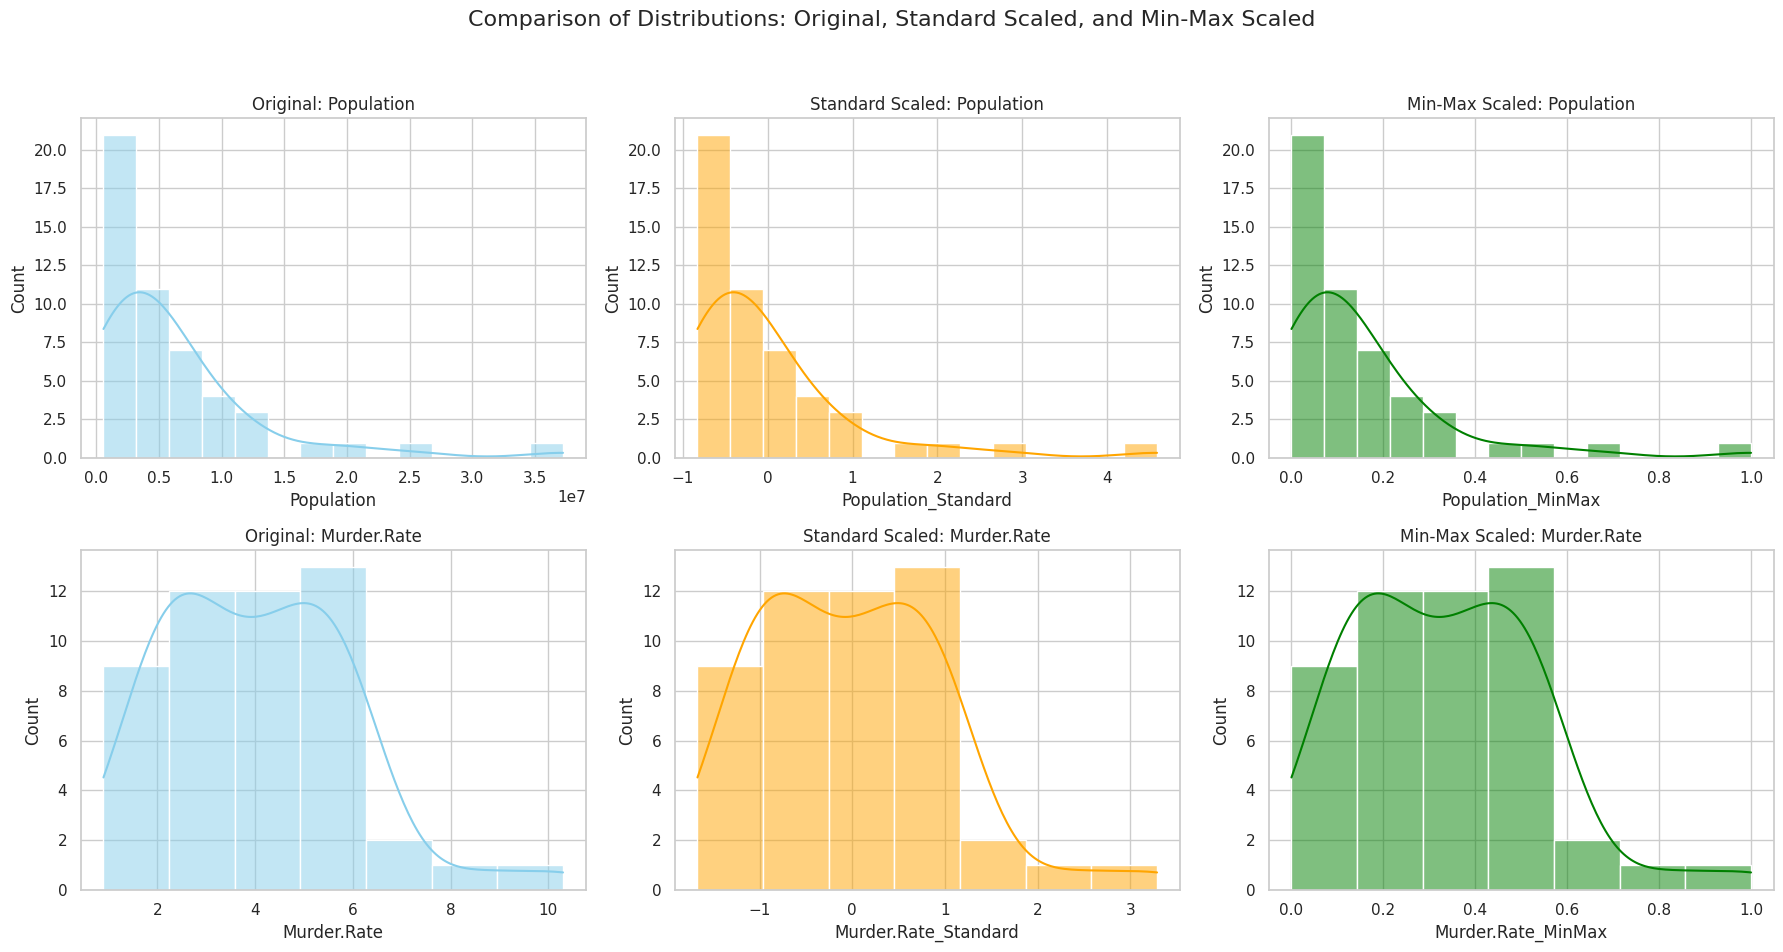

In [ ]:
# Set figure size and layout
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparison of Distributions: Original, Standard Scaled, and Min-Max Scaled', fontsize=16)

# Define columns and colors for iteration
# Row 0: Population, Row 1: Murder.Rate
variable_groups = [
    ('Population', 'Population_Standard', 'Population_MinMax'),
    ('Murder.Rate', 'Murder.Rate_Standard', 'Murder.Rate_MinMax')
]
colors = ['skyblue', 'orange', 'green']
plot_types = ['Original', 'Standard Scaled', 'Min-Max Scaled']

# Loop through rows (variables) and columns (scaling types) to create plots
for i, (orig, std, minmax) in enumerate(variable_groups):
    cols_to_plot = [orig, std, minmax]
    for j, col in enumerate(cols_to_plot):
        sns.histplot(df[col], kde=True, ax=axes[i, j], color=colors[j])
        axes[i, j].set_title(f'{plot_types[j]}: {variable_groups[i][0]}')
        axes[i, j].set_xlabel(col)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Summary of Findings

1.  **Outliers**:
    *   **Population**: Significant outliers were identified (e.g., California, Texas, New York, Florida). The distribution is highly right-skewed, with most states having smaller populations and a few states having extremely large populations.
    *   **Murder Rate**: One outlier was identified (Louisiana). The distribution is relatively more balanced but still does not follow a normal curve.

2.  **Impact of Scaling**:
    *   **Standard Scaling**: This centered the data around 0 with a standard deviation of 1. While the scale of the x-axis changed, the shape of the distribution (including skewness) remained exactly the same as the original.
    *   **Min-Max Scaling**: This compressed the data into the range [0, 1]. The presence of outliers in the 'Population' feature caused the majority of the data points to be squashed into a very small range near 0 (e.g., 0.0 to 0.2), illustrating how Min-Max scaling is sensitive to outliers.

3.  **Normality**:
    *   As confirmed by the Shapiro-Wilk tests and visualized in the histograms, neither 'Population' nor 'Murder.Rate' follows a normal distribution. Both features exhibit skewness that scaling alone does not correct (scaling changes range, not distribution shape).

## Final Task

### Subtask:
Summarize the findings regarding outliers, normality, and scaling effects.


## Summary:

### Q&A

**Q: Which states are considered outliers based on the IQR method?**
**A:** For the 'Population' column, **4 states** were identified as outliers: **California** (37,253,956), **Texas** (25,145,561), **New York** (19,378,102), and **Florida** (18,801,310), as they exceeded the upper bound of approximately **13,951,274**. For 'Murder.Rate', **Louisiana** (10.3) was the single outlier, slightly exceeding the upper bound of **10.24**.

**Q: Do the numerical features follow a normal distribution?**
**A:** No. The Shapiro-Wilk test rejected the null hypothesis for both columns. 'Population' had a p-value of approximately **1.86e-08**, and 'Murder.Rate' had a p-value of approximately **0.016**, confirming that neither feature is normally distributed.

### Data Analysis Key Findings

*   **Data Integrity**: The dataset contains **50 rows** and 4 columns with **0 duplicate rows** and **0 missing values**.
*   **Population Distribution**: The data is highly right-skewed. The maximum value is over **37 million** (California), while the statistical upper bound for non-outliers is only **~13.95 million**.
*   **Scaling Effects**:
    *   **Standard Scaling**: Successfully centered the data around 0 with a standard deviation of 1 but preserved the original skewness.
    *   **Min-Max Scaling**: Due to the extreme population outliers, the majority of the 'Population' data points were compressed into the bottom **20%** of the range (values between 0.0 and 0.2).

### Insights or Next Steps

*   **Sensitivity to Outliers**: The analysis demonstrates that Min-Max scaling is highly sensitive to outliers, causing "squashing" of non-outlier data. It is advisable to handle outliers (e.g., via capping or removal) or use robust scaling methods (like `RobustScaler`) before applying Min-Max scaling.
*   **Transformation Required**: Since the 'Population' data is not normal and spans several orders of magnitude, applying a **Log Transformation** would likely be more effective than simple linear scaling to normalize the distribution for machine learning models.
